## 1) Importar librerías y utilidades

In [1]:
# Importar librerías estándar y utilidades del proyecto
import os
from pathlib import Path
import sys
import json
import logging
import numpy as np
import pandas as pd

root = Path.cwd().resolve()
for _ in range(6):
    if (root / 'pyproject.toml').exists() or (root / 'setup.py').exists():
        break
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print(f'Added to sys.path: {root}')
# ------------------------------------------------------------

# Visualización en notebook
from IPython.display import Image, display

# Intentar importar las utilidades de monitoreo que creamos en src/monitoring
try:
    from src.monitoring import BaselineEstablisher, SyntheticDriftGenerator, DataDriftMonitor, DriftVisualizations
except Exception as e:
    raise ImportError(f'No se pueden importar utilidades de monitoreo: {e}')

# Scikit-learn usado para entrenar un pipeline simple (si es necesario)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('notebook')

Added to sys.path: C:\Users\Adrian\MLOpsFaseFinal\ObesityMine53


## 2) Cargar datos (baseline)

In [2]:
# Determinar la ruta de datos (usa `root` si fue calculado en la celda anterior)
DATA_PATH = (root / 'data' / 'obesity_estimation_cleaned.csv') if 'root' in globals() else Path('data/obesity_estimation_cleaned.csv')
DATA_PATH = Path(DATA_PATH)
print('Buscando archivo de datos en:', DATA_PATH.resolve())
# Si no existe, listar el directorio para diagnóstico antes de fallar
if not DATA_PATH.exists():
    data_dir = DATA_PATH.parent
    print('Archivo no encontrado. Contenido del directorio de datos:')
    if data_dir.exists():
        for p in sorted(data_dir.iterdir()):
            print(' -', p.name)
    raise FileNotFoundError(f'Archivo de datos no encontrado: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
# Normalizar nombres de columnas a minúsculas
df.columns = [c.lower() for c in df.columns]

logger.info(f'Datos cargados: {df.shape}')
display(df.head())

INFO:notebook:Datos cargados: (1909, 18)


Buscando archivo de datos en: C:\Users\Adrian\MLOpsFaseFinal\ObesityMine53\data\obesity_estimation_cleaned.csv


,gender,age,height,weight,family_history_with_overweight,favc,fcvc,ncp,caec,smoke,ch2o,scc,faf,tue,calc,mtrans,nobeyesdad,imc
0,female,21.0,1.62,64.0,yes,no,2.0,3.0,sometimes,no,2.0,no,0.0,1.0,no,public_transportation,1,24.386526
1,female,21.0,1.52,56.0,yes,no,3.0,3.0,sometimes,yes,3.0,yes,3.0,0.0,sometimes,public_transportation,1,24.238227
2,male,23.0,1.80,77.0,yes,no,2.0,3.0,sometimes,no,2.0,no,2.0,1.0,frequently,public_transportation,1,23.765432
3,male,27.0,1.80,87.0,no,no,3.0,3.0,sometimes,no,2.0,no,2.0,0.0,frequently,walking,2,26.851852
4,male,22.0,1.78,89.8,no,no,2.0,1.0,sometimes,no,2.0,no,0.0,0.0,sometimes,public_transportation,3,28.342381


## 3) Preparar target y dividir para establecer baseline

In [3]:
# Selección del target: usar 'nobeyesdad' si está disponible, si no usar umbral sobre 'imc'
if 'nobeyesdad' in df.columns:
    target_col = 'nobeyesdad'
    y_raw = df[target_col]
else:
    target_col = 'imc'
    y_raw = (df['imc'] > 25).astype(int)

# Características: excluir el target y la columna 'imc' si no es target
features = [c for c in df.columns if c not in ['nobeyesdad','imc']]
X = df[features].copy()

# Factorizar etiquetas (numéricas) para facilidad
y = pd.factorize(y_raw)[0]

# División simple para baseline
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
logger.info(f'Tamaño entrenamiento: {len(X_train)}, validación: {len(X_val)}')

INFO:notebook:Tamaño entrenamiento: 1527, validación: 382


## 4) Entrenar un pipeline simple (si no hay artefacto) y calcular la baseline de desempeño

In [4]:
# Construir pipeline sencillo para columnas numéricas y categóricas
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

clf = Pipeline([('pre', preprocessor),('clf', LogisticRegression(max_iter=1000))])

# Entrenar el pipeline
clf.fit(X_train, y_train)

# Calcular métricas baseline en el conjunto de validación
y_val_pred = clf.predict(X_val)
baseline_metrics = {'accuracy': float(accuracy_score(y_val, y_val_pred)), 'f1_weighted': float(f1_score(y_val, y_val_pred, average='weighted'))}
logger.info(f'Métricas baseline: {baseline_metrics}')
# Mostrar métricas en el notebook
display(baseline_metrics)

# Guardar pipeline entrenado para uso en monitoring (artefactos)
try:
    import joblib
    OUT_PIPE = Path('artefactos') / 'pipelines_optimizados.joblib'
    OUT_PIPE.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(clf, OUT_PIPE)
    logger.info(f'Pipeline guardado en {OUT_PIPE}')
except Exception as e:
    logger.warning(f'No se pudo guardar el pipeline: {e}')

baseline_metrics

INFO:notebook:Métricas baseline: {'accuracy': 0.8795811518324608, 'f1_weighted': 0.8781378793107103}


{'accuracy': 0.8795811518324608, 'f1_weighted': 0.8781378793107103}

INFO:notebook:Pipeline guardado en artefactos\pipelines_optimizados.joblib


{'accuracy': 0.8795811518324608, 'f1_weighted': 0.8781378793107103}

## 5) Establecer estadísticas de baseline y generar drift sintético

In [5]:
baseline_df = X_val.copy()
baseline_df['__target__'] = y_val
establisher = BaselineEstablisher(validation_data=baseline_df)
baseline_stats = establisher.compute_feature_statistics()
len(baseline_stats), list(baseline_stats.keys())[:10]

# Generador de drift sintético
generator = SyntheticDriftGenerator(baseline_data=baseline_df, random_state=123)
# Escenario: desplazamiento de media en 'weight' y 'height'
monitoring_df = generator.create_mean_shift_drift(features=['weight','height'], shift_magnitude=1.0, sample_size=len(baseline_df))
# Mantener target real para fines de evaluación
monitoring_df['__target__'] = baseline_df['__target__'].values
monitoring_df.head()

INFO:src.monitoring.monitoring_utils:Initialized BaselineEstablisher with 382 samples
INFO:src.monitoring.monitoring_utils:Initialized SyntheticDriftGenerator with 382 baseline samples
INFO:src.monitoring.monitoring_utils:Created mean-shift drift with 382 samples
INFO:src.monitoring.monitoring_utils:Initialized SyntheticDriftGenerator with 382 baseline samples
INFO:src.monitoring.monitoring_utils:Created mean-shift drift with 382 samples


,gender,age,height,weight,family_history_with_overweight,favc,fcvc,ncp,caec,smoke,ch2o,scc,faf,tue,calc,mtrans,__target__
993,female,35.456326,1.734444,102.105204,yes,yes,2.156065,2.909117,sometimes,no,1.221281,no,0.503279,1.796136,no,automobile,2
806,female,33.732714,1.766377,102.849055,yes,yes,3.000000,1.137150,sometimes,no,1.000695,no,0.261274,0.000000,sometimes,automobile,2
1457,male,28.992809,2.000858,156.022219,yes,yes,2.206119,3.000000,sometimes,no,1.483856,no,1.113169,0.000000,sometimes,public_transportation,5
858,female,31.793937,1.746232,95.408354,yes,yes,2.372494,2.849848,sometimes,no,1.028538,no,0.675983,0.303025,sometimes,automobile,5
856,female,17.258130,1.687884,88.956549,yes,yes,2.749629,2.298612,sometimes,no,2.000000,yes,0.547515,1.619473,sometimes,public_transportation,6


## 6) Evaluar desempeño sobre los datos con drift y detectar drift por feature

In [6]:
# Evaluar el modelo entrenado sobre los datos de monitoring
X_monitor = monitoring_df.drop(columns=['__target__'])
y_monitor = monitoring_df['__target__'].values
y_monitor_pred = clf.predict(X_monitor)
monitoring_metrics = {'accuracy': float(accuracy_score(y_monitor, y_monitor_pred)), 'f1_weighted': float(f1_score(y_monitor, y_monitor_pred, average='weighted'))}
logger.info(f'Métricas en monitoring: {monitoring_metrics}')

# Detectar drift por feature
drift_monitor = DataDriftMonitor()
numeric_feats = [f for f in baseline_df.select_dtypes(include=[np.number]).columns if f != '__target__']
categorical_feats = baseline_df.select_dtypes(include=['object','category']).columns.tolist()
drift_metrics, alerts = drift_monitor.detect_feature_drift(baseline_df, monitoring_df, numeric_features=numeric_feats, categorical_features=categorical_feats)
len([d for d in drift_metrics if d.drift_detected]), len(alerts)

INFO:notebook:Métricas en monitoring: {'accuracy': 0.13089005235602094, 'f1_weighted': 0.11794844475595646}
INFO:src.monitoring.drift_detection:Initialized Kolmogorov-Smirnov with threshold=0.05
INFO:src.monitoring.drift_detection:Initialized Wasserstein with threshold=0.3
INFO:src.monitoring.drift_detection:Initialized Hellinger with threshold=0.1
INFO:src.monitoring.drift_detection:Initialized DataDriftMonitor with 3 detectors
INFO:src.monitoring.drift_detection:Initialized Kolmogorov-Smirnov with threshold=0.05
INFO:src.monitoring.drift_detection:Initialized Wasserstein with threshold=0.3
INFO:src.monitoring.drift_detection:Initialized Hellinger with threshold=0.1
INFO:src.monitoring.drift_detection:Initialized DataDriftMonitor with 3 detectors


(10, 10)

## 7) Detectar degradación de performance y generar recomendaciones

In [7]:
# Detectar degradación en F1 con respecto a baseline
perf_detected, perf_alert = drift_monitor.detect_performance_drift(
    baseline_metrics={'f1_score': baseline_metrics.get('f1_weighted')},
    monitoring_metrics={'f1_score': monitoring_metrics.get('f1_weighted')},
    metric_name='f1_score'
)
perf_detected, perf_alert.to_dict() if perf_alert is not None else None

(True,
 {'timestamp': '2025-11-15T10:33:36.379719',
  'feature_name': 'f1_score',
  'drift_type': 'performance',
  'severity': 'medium',
  'drift_score': 0.7601894345547539,
  'threshold': 0.05,
  'suggested_action': 'CRITICAL: f1_score degraded by 76.0%. Recommend immediate model retraining with recent data.',
  'details': {'baseline_value': 0.8781378793107103,
   'monitoring_value': 0.11794844475595646,
   'degradation_pct': 86.56834563969163}})

## 8) Guardar reporte y visualizar resultados

INFO:notebook:Reporte guardado en artefactos\drift_monitoring_notebook\drift_report.json
INFO:src.monitoring.visualizations:Matplotlib and seaborn initialized
INFO:src.monitoring.visualizations:Matplotlib and seaborn initialized
INFO:src.monitoring.visualizations:Saved distribution plot to artefactos\drift_monitoring_notebook\dist_age.png
INFO:src.monitoring.visualizations:Saved distribution plot to artefactos\drift_monitoring_notebook\dist_age.png


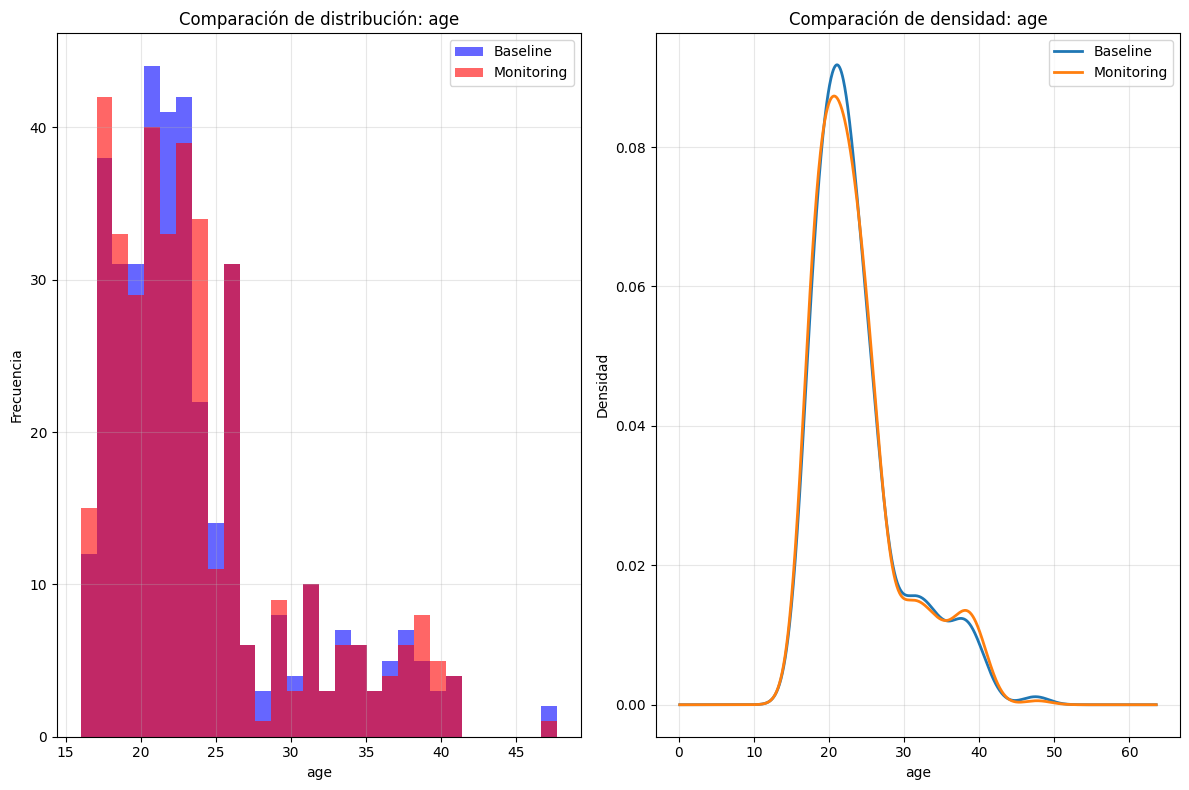

INFO:src.monitoring.visualizations:Saved performance metrics plot to artefactos\drift_monitoring_notebook\performance_comparison.png


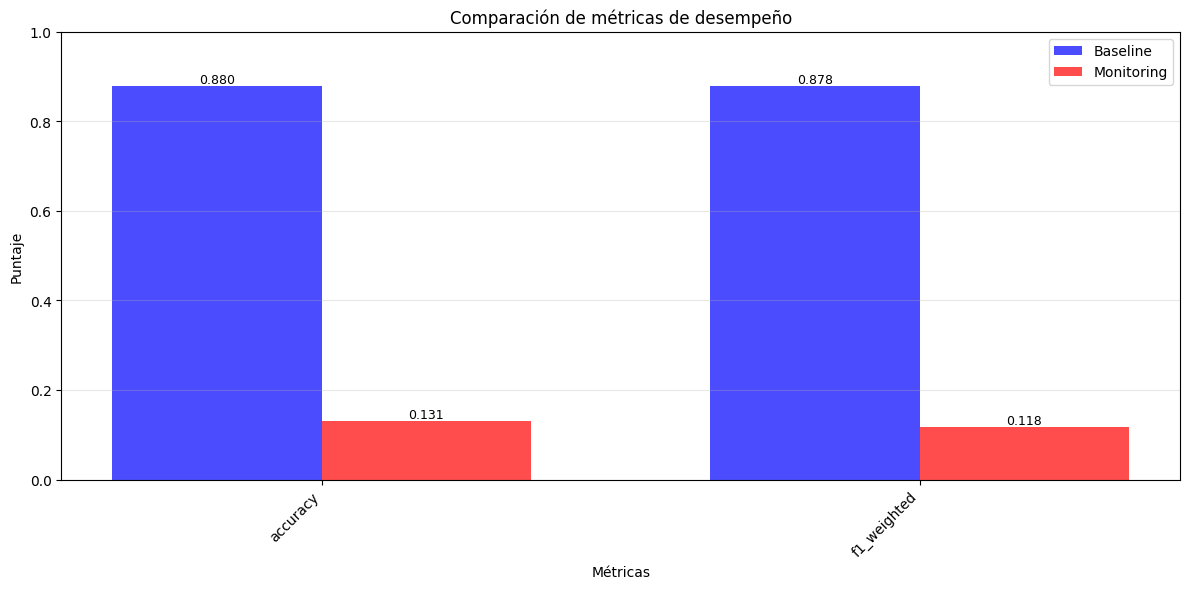

In [8]:
OUT = Path('artefactos/drift_monitoring_notebook')
OUT.mkdir(parents=True, exist_ok=True)
report = {
    'baseline_metrics': baseline_metrics,
    'monitoring_metrics': monitoring_metrics,
    'feature_drift_count': len([d for d in drift_metrics if d.drift_detected]),
    'alerts': [a.to_dict() for a in alerts],
    'performance_alert': perf_alert.to_dict() if perf_alert is not None else None
}
(OUT / 'drift_report.json').write_text(json.dumps(report, indent=2))
logger.info(f'Reporte guardado en {OUT / "drift_report.json"}')

# Visualizaciones: comparar distribución para la primera feature numérica detectada
viz = DriftVisualizations()
if numeric_feats:
    feat = numeric_feats[0]
    img_path = OUT / f'dist_{feat}.png'
    viz.plot_feature_distribution_comparison(baseline_df, monitoring_df, feat, output_path=img_path)
    display(Image(filename=str(img_path)))

# Gráfico de métricas de desempeño
perf_img = OUT / 'performance_comparison.png'
viz.plot_performance_metrics(baseline_metrics, monitoring_metrics, output_path=perf_img)
display(Image(filename=str(perf_img)))